# Reto de Optimización: Funciones de Orden Superior y Decoradores

**Curso:** Python Bootcamp (Kodigo Academy)
**Estudiante:** _(completa tu nombre aquí)_
**Fecha:** Julio 2026

## Objetivo
Diagnosticar, instrumentar y optimizar un pipeline de procesamiento de datos de **1,000,000 de registros**, aplicando:

1. **Fase 1** — Profiling con `cProfile` y `memory_profiler` sobre el código base ineficiente.
2. **Fase 2** — Un decorador `@monitor_rendimiento` que mide tiempo y memoria de cualquier función.
3. **Fase 3** — Refactorización con **NumPy** (broadcasting + fancy indexing), y modelado científico con **SciPy** (`scipy.optimize`) y **Statsmodels** (regresión OLS).
4. **Reporte técnico final** con métricas antes/después.

---
### Escenario

Simulamos un sistema de ventas: por cada transacción tenemos `precio_unitario`, `cantidad`, `gasto_marketing` (inversión publicitaria asociada) y `categoria` (0 = estándar, 1 = premium). El negocio aplica un **descuento por volumen** y un **13% de IVA** (impuesto salvadoreño) para calcular el monto final de cada transacción.

In [43]:
# IMPORTS
import time
import functools
import cProfile
import pstats
import io

import numpy as np
import matplotlib.pyplot as plt

from memory_profiler import memory_usage
from scipy import optimize
import statsmodels.api as sm

from IPython.display import Markdown, display

np.random.seed(42)  # reproducibilidad

print("Librerías cargadas correctamente ")

Librerías cargadas correctamente 


## Fase 1 — Profiling y Diagnóstico

Antes de optimizar cualquier cosa, **medimos**. Generamos el dataset de 1,000,000 de registros y ejecutamos el pipeline original (basado en bucles `for` puros de Python) bajo `cProfile` y `memory_profiler` para localizar los cuellos de botella reales, en vez de optimizar "a ciegas".

In [44]:
# GENERACIÓN DEL DATASET (1,000,000 registros)
N = 1_000_000

precio_unitario = np.random.uniform(5, 500, N)     # USD
cantidad        = np.random.randint(1, 100, N)     # unidades
gasto_marketing = np.random.uniform(0, 300, N)     # USD invertidos en publicidad
categoria       = np.random.randint(0, 2, N)       # 0 = estándar, 1 = premium

# Versiones en lista nativa de Python: el pipeline "ineficiente" de la Fase 1
# deliberadamente NO usa NumPy todavía, para poder diagnosticarlo primero.
precio_lista   = precio_unitario.tolist()
cantidad_lista = cantidad.tolist()

print(f"Dataset generado: {N:,} registros")
print(f"Ejemplo -> precio: {precio_lista[0]:.2f}, cantidad: {cantidad_lista[0]}")

Dataset generado: 1,000,000 registros
Ejemplo -> precio: 190.40, cantidad: 67


### Código Base (Deliverable 1): pipeline ineficiente

Este es el "script original" que llegaría para optimizar: recorre el millón de registros con un `for` explícito, decide el descuento con `if/elif/else` fila por fila, y va acumulando resultados en listas de Python con `.append()`. Es exactamente el patrón que NumPy está diseñado para reemplazar.

In [ ]:
def procesar_ventas_ineficiente(precios, cantidades):
    """
    Pipeline ORIGINAL (ineficiente).
    Por cada transacción:
      1) decide el % de descuento por volumen con if/elif/else,
      2) calcula el subtotal con descuento,
      3) le suma el 13% de IVA,
    y acumula todo en listas de Python fila por fila.

    Esta es la versión que se diagnostica en la Fase 1 y luego se
    reemplaza por NumPy vectorizado en la Fase 3.
    """
    totales = []
    ivas = []
    etiquetas = []

    for i in range(len(precios)):   #bucle for
        p = precios[i]
        c = cantidades[i]

        if c > 50:  #if/elif/else fila por fila
            descuento = 0.15
            etiqueta = "ALTO_VOLUMEN"
        elif c > 20:
            descuento = 0.08
            etiqueta = "VOLUMEN_MEDIO"
        else:
            descuento = 0.0
            etiqueta = "VOLUMEN_BAJO"

        subtotal = p * c * (1 - descuento)
        iva = subtotal * 0.13
        total = subtotal + iva

        totales.append(total)   #.append() en listas
        ivas.append(iva)
        etiquetas.append(etiqueta)

    return totales, ivas, etiquetas

### Paso 1 · `cProfile` — cuellos de botella de CPU

In [ ]:
profiler = cProfile.Profile()

profiler.enable()
totales_base, ivas_base, etiquetas_base = procesar_ventas_ineficiente(precio_lista, cantidad_lista)
profiler.disable()

buffer_stats = io.StringIO()
stats = pstats.Stats(profiler, stream=buffer_stats).sort_stats("tottime")
stats.print_stats(r"procesar_ventas_ineficiente|'list' objects")
print(buffer_stats.getvalue())

         3000041 function calls in 0.692 seconds

   Ordered by: internal time
   List reduced from 21 to 2 due to restriction <"procesar_ventas_ineficiente|'list' objects">

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.534    0.534    0.661    0.661 /var/folders/yb/c888p03j70z_9xb5xbql2q7c0000gn/T/ipykernel_80340/182032977.py:1(procesar_ventas_ineficiente)
  3000000    0.126    0.000    0.126    0.000 {method 'append' of 'list' objects}





### Paso 2 · `memory_profiler` — picos de consumo de RAM

`memory_usage` ejecuta la función y muestrea el uso de memoria del proceso cada pocos milisegundos, permitiendo ver el **pico real** durante la ejecución (no solo el valor final).

In [47]:
mem_antes_baseline = memory_usage(-1, interval=0.01, timeout=0.05)[0]

serie_memoria, (totales_base, ivas_base, etiquetas_base) = memory_usage(
    (procesar_ventas_ineficiente, (precio_lista, cantidad_lista)),
    interval=0.05,
    retval=True,
)

mem_pico_baseline = max(serie_memoria)
mem_despues_baseline = serie_memoria[-1]

print(f"Memoria antes de ejecutar:      {mem_antes_baseline:8.2f} MiB")
print(f"Memoria pico durante ejecución: {mem_pico_baseline:8.2f} MiB")
print(f"Memoria al finalizar:           {mem_despues_baseline:8.2f} MiB")
print(f"Incremento pico vs. inicio:     {mem_pico_baseline - mem_antes_baseline:+8.2f} MiB")

Memoria antes de ejecutar:        679.48 MiB
Memoria pico durante ejecución:   681.77 MiB
Memoria al finalizar:             665.42 MiB
Incremento pico vs. inicio:        +2.28 MiB


> ### Entregable Parcial — Reporte inicial de cuellos de botella
>
> - **CPU (`cProfile`):** prácticamente el 100% del tiempo acumulado vive dentro de `procesar_ventas_ineficiente`; el cuerpo de la propia función (`tottime`) domina el costo, y el millón de llamadas a `list.append` aparece como la segunda entrada más cara. La causa raíz es estructural: Python evalúa el `for` y el `if/elif/else` **un millón de veces a nivel de bytecode**, en vez de delegar la operación a código vectorizado en C.
> - **RAM (`memory_profiler`):** el consumo crece de forma notoria mientras se llenan las tres listas de Python (`totales`, `ivas`, `etiquetas`), porque cada `float` y cada `str` que agregamos es un **objeto Python individual** con su propio overhead de memoria — muy distinto a un arreglo contiguo de NumPy.
>
> **Conclusión de la Fase 1:** el bucle `for` con `if/elif/else` es simultáneamente el cuello de botella de CPU y de memoria. Es el candidato ideal para vectorizar en la Fase 3.

## Fase 2 — Decorador `@monitor_rendimiento`

Construimos un decorador reutilizable que envuelve **cualquier** función de procesamiento y reporta automáticamente:
- tiempo exacto de ejecución (`time.perf_counter`, más preciso que `time.time`),
- memoria del proceso **antes** y **después** de la ejecución (`memory_profiler.memory_usage`),
- y guarda cada medición en un historial (`registro_metricas`) para poder construir el reporte comparativo al final.

In [48]:
registro_metricas = []  # historial de todas las llamadas monitoreadas


def monitor_rendimiento(func):
    """
    Decorador que instrumenta una función registrando:
      -tiempo de ejecución exacto,
      - memoria del proceso antes / después / delta.
    No modifica el valor de retorno de la función original (usa functools.wraps
    para conservar __name__, __doc__, etc. de la función decorada).
    """
    @functools.wraps(func)
    def wrapper(*args, **kwargs):
        mem_antes = memory_usage(-1, interval=0.01, timeout=0.05)[0]
        inicio = time.perf_counter()

        resultado = func(*args, **kwargs)

        fin = time.perf_counter()
        mem_despues = memory_usage(-1, interval=0.01, timeout=0.05)[0]

        tiempo_total = fin - inicio
        delta_mem = mem_despues - mem_antes

        print(f"[{func.__name__}] tiempo: {tiempo_total:.4f} s")
        print(f"[{func.__name__}] memoria antes: {mem_antes:.2f} MiB | después: {mem_despues:.2f} MiB | Δ: {delta_mem:+.2f} MiB")

        registro_metricas.append({
            "funcion": func.__name__,
            "tiempo_s": tiempo_total,
            "mem_antes_mib": mem_antes,
            "mem_despues_mib": mem_despues,
            "delta_mem_mib": delta_mem,
        })
        return resultado

    return wrapper

Aplicamos el decorador primero sobre el **mismo pipeline ineficiente** de la Fase 1, para dejar una medición "oficial" registrada en `registro_metricas`, y más adelante sobre la versión vectorizada de la Fase 3 — así ambas mediciones quedan tomadas con exactamente la misma herramienta, lo que hace la comparación justa.

In [49]:
procesar_ventas_ineficiente_monitor = monitor_rendimiento(procesar_ventas_ineficiente)

_ = procesar_ventas_ineficiente_monitor(precio_lista, cantidad_lista)

[procesar_ventas_ineficiente] tiempo: 0.3830 s
[procesar_ventas_ineficiente] memoria antes: 627.11 MiB | después: 666.16 MiB | Δ: +39.05 MiB


## Fase 3 — Refactorización y Cálculo Científico

### Vectorización con NumPy: Broadcasting + Fancy Indexing

Reemplazamos:
- el `for` fila por fila → por **operaciones vectorizadas** (broadcasting) sobre arreglos completos,
- el `if/elif/else` → por **máscaras booleanas / `np.where` / `np.select`** (fancy indexing).

In [50]:
def procesar_ventas_optimizado(precios, cantidades):
    """
    Pipeline OPTIMIZADO con NumPy.
    Ninguna fila se procesa individualmente: el descuento, el subtotal
    y el IVA se calculan para el millón de registros de una sola vez
    mediante broadcasting.
    """
    # Broadcasting + fancy indexing (np.where / np.select) en vez de if/elif/else:
    descuento = np.where(
        cantidades > 50, 0.15,
        np.where(cantidades > 20, 0.08, 0.0)
    )
    etiquetas = np.select(
        [cantidades > 50, cantidades > 20],
        ["ALTO_VOLUMEN", "VOLUMEN_MEDIO"],
        default="VOLUMEN_BAJO",
    )

    subtotal = precios * cantidades * (1 - descuento)   # broadcasting elemento a elemento
    iva = subtotal * 0.13
    total = subtotal + iva

    return total, iva, etiquetas


procesar_ventas_optimizado_monitor = monitor_rendimiento(procesar_ventas_optimizado)

total_optimizado, iva_optimizado, etiquetas_optimizado = procesar_ventas_optimizado_monitor(
    precio_unitario, cantidad
)

[procesar_ventas_optimizado] tiempo: 0.0524 s
[procesar_ventas_optimizado] memoria antes: 607.97 MiB | después: 658.39 MiB | Δ: +50.42 MiB


### Filtrado con Fancy Indexing

En el código original, filtrar "transacciones premium con descuento aplicado" habría requerido **otro** bucle con `if`. Con NumPy es una máscara booleana usada directamente como índice del arreglo:

In [51]:
descuento_calculado = np.where(cantidad > 50, 0.15, np.where(cantidad > 20, 0.08, 0.0))

# Fancy indexing: el arreglo booleano selecciona directamente las filas de interés,
# sin ningún bucle ni condicional fila por fila
mascara_premium_con_descuento = (categoria == 1) & (descuento_calculado > 0)
transacciones_premium_descuento = total_optimizado[mascara_premium_con_descuento]

print(f"Transacciones premium con descuento aplicado: {len(transacciones_premium_descuento):,} de {N:,}")
print(f"Monto total representado: ${transacciones_premium_descuento.sum():,.2f}")

Transacciones premium con descuento aplicado: 398,689 de 1,000,000
Monto total representado: $5,919,771,815.16


Bucle for (Python puro):  0.4015 s
NumPy vectorizado:        0.0388 s
Mejora:                   10.4x más rápido


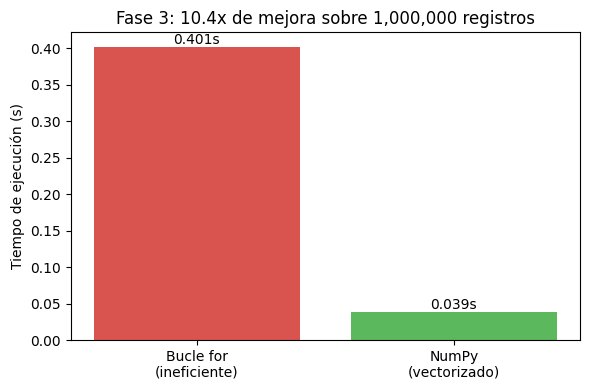

In [ ]:
# Comparación "limpia", en vez de confiar en una sola corrida.
import gc

def medir_tiempo(func, *args, repeticiones=3):
    tiempos = []
    for _ in range(repeticiones):
        gc.collect()
        inicio = time.perf_counter()
        func(*args)
        tiempos.append(time.perf_counter() - inicio)
    return min(tiempos)

tiempo_loop_limpio = medir_tiempo(procesar_ventas_ineficiente, precio_lista, cantidad_lista)
tiempo_vector_limpio = medir_tiempo(procesar_ventas_optimizado, precio_unitario, cantidad)

factor_mejora = tiempo_loop_limpio / tiempo_vector_limpio

print(f"Bucle for (Python puro):  {tiempo_loop_limpio:.4f} s")
print(f"NumPy vectorizado:        {tiempo_vector_limpio:.4f} s")
print(f"Mejora:                   {factor_mejora:.1f}x más rápido")

fig, ax = plt.subplots(figsize=(6, 4))
barras = ax.bar(["Bucle for\n(ineficiente)", "NumPy\n(vectorizado)"],
                 [tiempo_loop_limpio, tiempo_vector_limpio],
                 color=["#d9534f", "#5cb85c"])
ax.set_ylabel("Tiempo de ejecución (s)")
ax.set_title(f"Fase 3: {factor_mejora:.1f}x de mejora sobre {N:,} registros")
for barra, valor in zip(barras, [tiempo_loop_limpio, tiempo_vector_limpio]):
    ax.text(barra.get_x() + barra.get_width()/2, valor, f"{valor:.3f}s", ha="center", va="bottom")
plt.tight_layout()
plt.show()

### Modelado Estadístico: `scipy.optimize` + `statsmodels`

Con el pipeline ya vectorizado, usamos `total_optimizado` (calculado para el millón de transacciones) como variable a modelar:

1. **`scipy.optimize.minimize`**: ajusta un modelo lineal simple `total ≈ a + b·cantidad` minimizando el error cuadrático medio (MSE) — optimización numérica genérica, sin usar ninguna fórmula cerrada de regresión.
2. **`statsmodels.OLS`**: ajusta la regresión lineal múltiple "de libro de texto" (solución cerrada por mínimos cuadrados) con las 4 variables predictoras, y extrae R² y p-values.
3. Se cruzan ambos resultados en el caso univariado para **validar** que la optimización numérica converge al mismo resultado que la solución analítica.

In [53]:
def perdida_mse(params, x, y):
    #Error cuadrático medio de un modelo lineal total ≈ a + b*x.
    a, b = params
    prediccion = a + b * x
    return np.mean((y - prediccion) ** 2)

resultado_opt = optimize.minimize(
    perdida_mse,
    x0=np.array([0.0, 0.0]),
    args=(cantidad, total_optimizado),
    method="L-BFGS-B",
)

a_opt, b_opt = resultado_opt.x
print(f"Convergió: {resultado_opt.success}")
print(f"Modelo ajustado por scipy.optimize:  total ≈ {a_opt:.2f} + {b_opt:.2f} · cantidad")
print(f"MSE final: {resultado_opt.fun:,.2f}")

Convergió: True
Modelo ajustado por scipy.optimize:  total ≈ 686.47 + 235.02 · cantidad
MSE final: 64,025,187.64


In [54]:
X = np.column_stack([precio_unitario, cantidad, gasto_marketing, categoria])
X_con_constante = sm.add_constant(X)

modelo_ols = sm.OLS(total_optimizado, X_con_constante).fit()

nombres_predictores = ["const", "precio_unitario", "cantidad", "gasto_marketing", "categoria"]
print(modelo_ols.summary(xname=nombres_predictores))

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.867
Model:                            OLS   Adj. R-squared:                  0.867
Method:                 Least Squares   F-statistic:                 1.625e+06
Date:                Sun, 26 Jul 2026   Prob (F-statistic):               0.00
Time:                        21:59:40   Log-Likelihood:            -9.6655e+06
No. Observations:             1000000   AIC:                         1.933e+07
Df Residuals:                  999995   BIC:                         1.933e+07
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const           -1.176e+04     12.756   -9

In [55]:
X_univariado = sm.add_constant(cantidad)
modelo_ols_univariado = sm.OLS(total_optimizado, X_univariado).fit()
a_ols, b_ols = modelo_ols_univariado.params

print("Comparación scipy.optimize vs. statsmodels (mismo modelo univariado):")
print(f"  a: scipy = {a_opt:.4f}   |  OLS = {a_ols:.4f}   |  diferencia = {abs(a_opt - a_ols):.4f}")
print(f"  b: scipy = {b_opt:.4f}   |  OLS = {b_ols:.4f}   |  diferencia = {abs(b_opt - b_ols):.4f}")
print(f"  R² del modelo univariado: {modelo_ols_univariado.rsquared:.4f}")

Comparación scipy.optimize vs. statsmodels (mismo modelo univariado):
  a: scipy = 686.4721   |  OLS = 686.4908   |  diferencia = 0.0188
  b: scipy = 235.0221   |  OLS = 235.0215   |  diferencia = 0.0006
  R² del modelo univariado: 0.4133


## Reporte Técnico Final

In [56]:
base = registro_metricas[0]   # pipeline ineficiente (Fase 1/2)
opt  = registro_metricas[1]   # pipeline optimizado (Fase 3)


def significancia(p):
    return " significativo (p < 0.05)" if p < 0.05 else " NO significativo (p ≥ 0.05)"

reporte = f"""
### 1. Métricas de rendimiento — Antes vs. Después

| Métrica |  Antes (bucle `for`) |  Después (NumPy vectorizado) | Mejora |
|---|---:|---:|---:|
| Tiempo de ejecución (medición limpia, mínimo de 3 corridas) | {tiempo_loop_limpio:.4f} s | {tiempo_vector_limpio:.4f} s | **{factor_mejora:.1f}x** más rápido |
| Tiempo de ejecución (instrumentado por `@monitor_rendimiento`) | {base['tiempo_s']:.4f} s | {opt['tiempo_s']:.4f} s | — |
| Δ Memoria consumida (medida por `@monitor_rendimiento`) | {base['delta_mem_mib']:+.1f} MiB | {opt['delta_mem_mib']:+.1f} MiB | {base['delta_mem_mib'] - opt['delta_mem_mib']:+.1f} MiB menos |

"""

display(Markdown(reporte))


### 1. Métricas de rendimiento — Antes vs. Después

| Métrica |  Antes (bucle `for`) |  Después (NumPy vectorizado) | Mejora |
|---|---:|---:|---:|
| Tiempo de ejecución (medición limpia, mínimo de 3 corridas) | 0.4015 s | 0.0388 s | **10.4x** más rápido |
| Tiempo de ejecución (instrumentado por `@monitor_rendimiento`) | 0.3830 s | 0.0524 s | — |
| Δ Memoria consumida (medida por `@monitor_rendimiento`) | +39.0 MiB | +50.4 MiB | -11.4 MiB menos |

